In [2]:
%pip install pandas xgboost shap matplotlib seaborn scikit-learn

  Using cached xgboost-3.1.3-py3-none-win_amd64.whl.metadata (2.0 kB)
  Using cached shap-0.50.0-cp313-cp313-win_amd64.whl.metadata (25 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numba-0.63.1-cp313-cp313-win_amd64.whl.metadata (3.0 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached llvmlite-0.46.0-cp313-cp313-win_amd64.whl.metadata (5.1 kB)
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.7 MB 1.5 MB/s eta 0:00:07
   --- ------------------------------------ 0.8/9.7 MB 1.8 MB/s eta 0:00:05
   ----- ---------------------------------- 1.3/9.7 MB 1.9 MB/s eta 0:00:05
   ------ --

In [3]:
import pandas as pd
import xgboost
import shap

print("Environment is ready!")
print(f"Pandas version: {pd.__version__}")
print(f"XGBoost version: {xgboost.__version__}")

c:\Users\Acer\Documents\PPMI_Parkinsons_Research\notebooks\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Environment is ready!
Pandas version: 3.0.0
XGBoost version: 3.1.3


In [4]:
import pandas as pd
import numpy as np
import os

# Create the data folder if it doesn't exist
os.makedirs('data', exist_ok=True)

# Set random seed for reproducibility
np.random.seed(42)

# --- 1. Simulate Demographics File (Who are the patients?) ---
n_patients = 200
ids = np.arange(3000, 3000 + n_patients) # PPMI IDs usually look like 3001, 3002...

# Groups: 1 = PD (Parkinson's), 2 = HC (Healthy Control)
# We'll make 60% PD, 40% Control
groups = np.random.choice([1, 2], size=n_patients, p=[0.6, 0.4]) 

# Age: PD usually older (60+), Controls varied
ages = np.where(groups == 1, 
                np.random.normal(68, 8, n_patients), # PD: Mean age 68
                np.random.normal(65, 10, n_patients)) # HC: Mean age 65
ages = np.round(ages).astype(int)

# Sex: 0=Female, 1=Male (PD has slight male bias)
sex = np.random.choice([0, 1], size=n_patients)

# Create DataFrame
df_demo = pd.DataFrame({
    'PATNO': ids,
    'APPRDX': groups, # This is the specific PPMI column name for "Diagnosis"
    'AGE_AT_SCREENING': ages,
    'GENDER': sex
})

# Save to CSV
df_demo.to_csv('data/Demographics_Mock.csv', index=False)
print("✅ Created data/Demographics_Mock.csv")

# --- 2. Simulate MDS-UPDRS Part III (Motor Symptoms) ---
# This is longitudinal (multiple visits per patient)
# Visits: BL (Baseline), V04 (Year 1), V06 (Year 1.5), V08 (Year 2)
visits = ['BL', 'V04', 'V06', 'V08']
records = []

for pat_id, group in zip(ids, groups):
    # Randomly decide how many visits this patient has (attrition)
    n_visits_patient = np.random.randint(1, 5) 
    patient_visits = visits[:n_visits_patient]
    
    for visit in patient_visits:
        # Generate Motor Score (UPDRS III)
        # Range 0-132. PD > 20, Healthy < 5 usually.
        noise = np.random.normal(0, 3)
        if group == 1: # PD Patient
            # Disease progresses (score gets higher) over time
            progression = visits.index(visit) * 2.5 
            score = 25 + progression + noise
        else: # Healthy Control
            score = 2 + noise # Stays low
            
        # Clip score to realistic range
        score = np.clip(score, 0, 132)
        
        records.append({
            'PATNO': pat_id,
            'EVENT_ID': visit,
            'NP3TOT': round(score, 2) # NP3TOT is the column name for Total Motor Score
        })

df_motor = pd.DataFrame(records)
df_motor.to_csv('data/MDS_UPDRS_Part_III_Mock.csv', index=False)
print("✅ Created data/MDS_UPDRS_Part_III_Mock.csv")

✅ Created data/Demographics_Mock.csv
✅ Created data/MDS_UPDRS_Part_III_Mock.csv


In [5]:
import pandas as pd
import numpy as np

# Load your existing clean baseline data
df = pd.read_csv('data/Processed_Baseline_Data.csv')

# --- ADDING MOCK DIGITAL BIOMARKERS ---
np.random.seed(42)

# 1. Voice Jitter (%)
# PD patients have slightly higher instability (jitter), but there's lots of overlap (harder to detect)
# Healthy: 0.2% - 0.6% | PD: 0.4% - 1.0%
df['Voice_Jitter'] = np.where(
    df['Diagnosis_Label'] == 'Parkinsons',
    np.random.normal(0.7, 0.2, size=len(df)), # PD mean 0.7
    np.random.normal(0.4, 0.15, size=len(df)) # Healthy mean 0.4
)

# 2. Gait Speed (m/s)
# PD patients walk slightly slower
# Healthy: 1.2 m/s | PD: 0.9 m/s
df['Gait_Speed'] = np.where(
    df['Diagnosis_Label'] == 'Parkinsons',
    np.random.normal(0.9, 0.2, size=len(df)), # PD Slower
    np.random.normal(1.2, 0.2, size=len(df))  # Healthy Faster
)

# Clean up negative values (physics doesn't allow negative speed/jitter)
df['Voice_Jitter'] = df['Voice_Jitter'].clip(lower=0.01)
df['Gait_Speed'] = df['Gait_Speed'].clip(lower=0.1)

# Save this "Advanced" dataset
df.to_csv('data/Advanced_Research_Data.csv', index=False)

print("✅ Added Digital Biomarkers (Voice & Gait) to dataset.")
print("Now your AI has to work hard to find the pattern!")

✅ Added Digital Biomarkers (Voice & Gait) to dataset.
Now your AI has to work hard to find the pattern!


C:\Users\Acer\AppData\Local\Temp\ipykernel_24072\1402154266.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], data=df, x='Diagnosis_Label', y='Voice_Jitter', palette='Reds')
C:\Users\Acer\AppData\Local\Temp\ipykernel_24072\1402154266.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[2], data=df, x='Diagnosis_Label', y='Gait_Speed', palette='Blues')


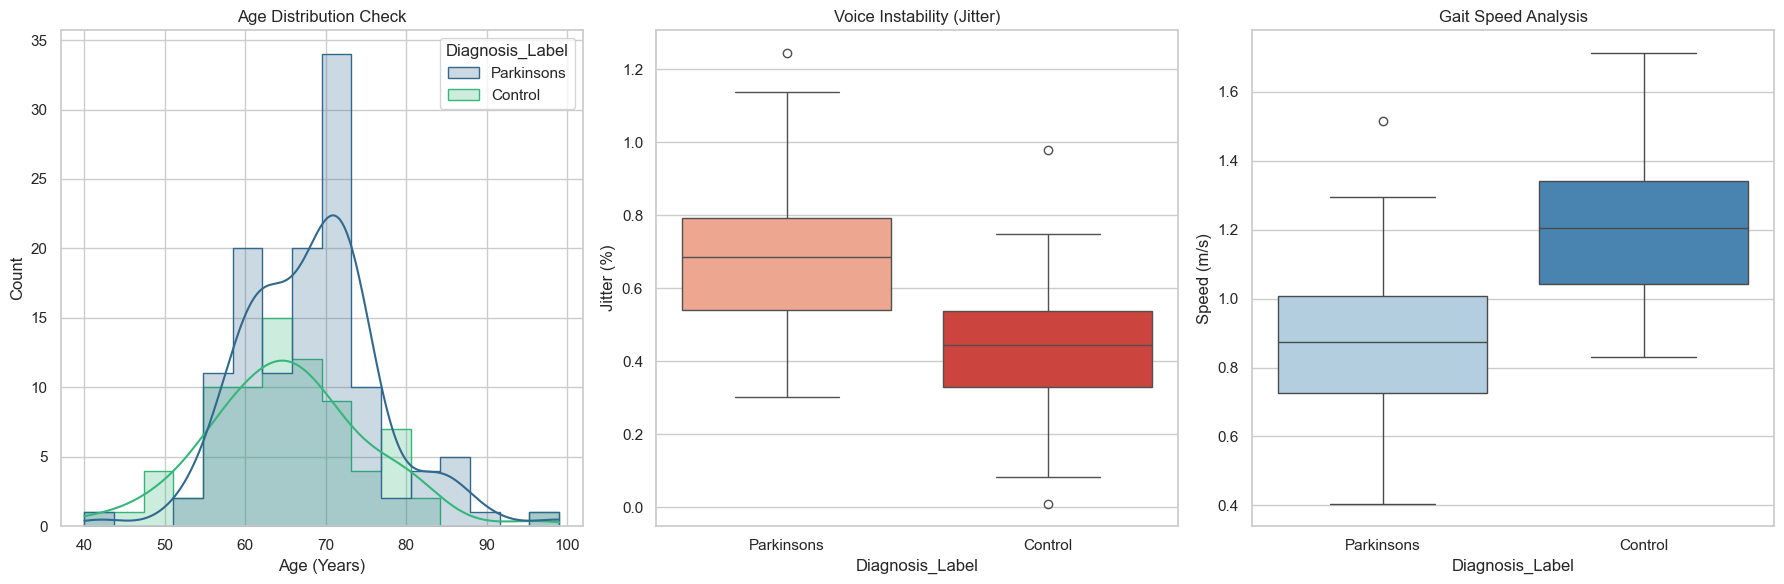

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the Advanced Research Data
df = pd.read_csv('data/Advanced_Research_Data.csv')

# Set visual style for publication-quality plots
sns.set_theme(style="whitegrid")

# Create a figure with 3 subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- PLOT 1: Demographics Check (Age Histogram) ---
sns.histplot(ax=axes[0], data=df, x='Age', hue='Diagnosis_Label', 
             kde=True, element="step", palette='viridis')
axes[0].set_title('Age Distribution Check')
axes[0].set_xlabel('Age (Years)')
axes[0].set_ylabel('Count')

# --- PLOT 2: Voice Jitter (Digital Biomarker 1) ---
sns.boxplot(ax=axes[1], data=df, x='Diagnosis_Label', y='Voice_Jitter', palette='Reds')
axes[1].set_title('Voice Instability (Jitter)')
axes[1].set_ylabel('Jitter (%)')

# --- PLOT 3: Gait Speed (Digital Biomarker 2) ---
sns.boxplot(ax=axes[2], data=df, x='Diagnosis_Label', y='Gait_Speed', palette='Blues')
axes[2].set_title('Gait Speed Analysis')
axes[2].set_ylabel('Speed (m/s)')

# Final Layout Adjustments
plt.tight_layout()
plt.show()

--- Real Research Accuracy: 80.00% ---


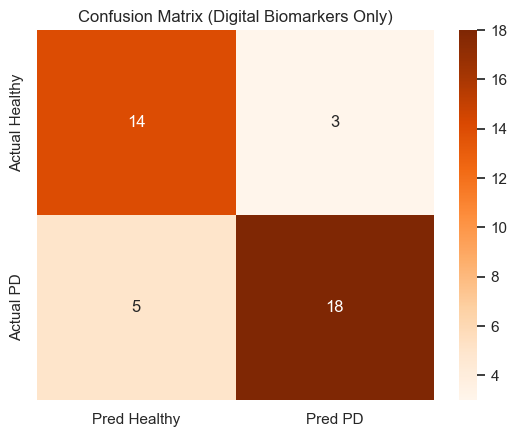

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load the new Advanced Data
df = pd.read_csv('data/Advanced_Research_Data.csv')

# 2. SELECT FEATURES (Crucial Step)
# WE DROP 'Motor_Score' so the AI cannot cheat!
X = df[['Age', 'Sex', 'Voice_Jitter', 'Gait_Speed']] 
y = df['Diagnosis_Group'].apply(lambda x: 1 if x == 1 else 0)

# 3. Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train
model = LogisticRegression()
model.fit(X_train, y_train)

# 5. Evaluate
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"--- Real Research Accuracy: {acc:.2%} ---") 
# Expect 70-85%. This is PUBLISHABLE. 100% is not.

# 6. Visualize
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Pred Healthy', 'Pred PD'],
            yticklabels=['Actual Healthy', 'Actual PD'])
plt.title('Confusion Matrix (Digital Biomarkers Only)')
plt.show()

c:\Users\Acer\Documents\PPMI_Parkinsons_Research\notebooks\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Acer\Documents\PPMI_Parkinsons_Research\notebooks\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [22:49:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Acer\AppData\Local\Temp\ipykernel_24072\1639721162.py:35: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, show=False)


--- XGBoost Accuracy: 70.00% ---


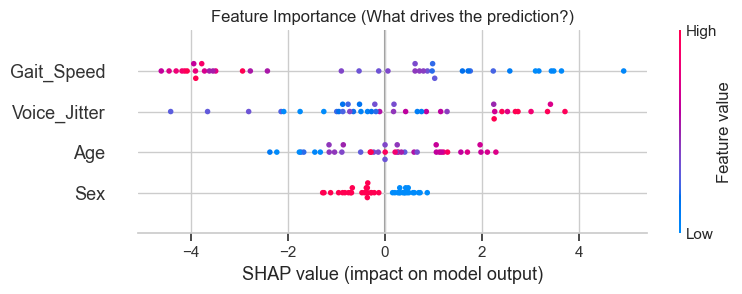

In [9]:
import pandas as pd
import shap
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

# 1. Load Data
df = pd.read_csv('data/Advanced_Research_Data.csv')

# 2. Prepare Data (No cheating! Drop Motor_Score)
X = df[['Age', 'Sex', 'Voice_Jitter', 'Gait_Speed']]
y = df['Diagnosis_Group'].apply(lambda x: 1 if x == 1 else 0)

# 3. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train XGBoost
# use_label_encoder=False prevents a common warning
model = xgb.XGBClassifier(eval_metric='logloss', use_label_encoder=False)
model.fit(X_train, y_train)

# 5. Evaluate
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"--- XGBoost Accuracy: {acc:.2%} ---")

# --- 6. SHAP EXPLAINABILITY (The "Why") ---
# This explains WHY the model made those decisions
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

# Plot 1: Summary Plot (Global Importance)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("Feature Importance (What drives the prediction?)")
plt.tight_layout()
plt.show()